In [1]:
# STEP 1: Load the Dataset

import pandas as pd
import numpy as np

# Path to the full dataset
file_path = '/content/Data/players_data-2026_2027.csv'

# Load CSV file into a pandas DataFrame
df = pd.read_csv(file_path)

# Display dataset dimensions (rows and columns)
print("Dataset loaded successfully!")
print(f"Total Players (Rows): {df.shape[0]}")
print(f"Total Features (Columns): {df.shape[1]}")

# Inspect the first 5 rows
df.head()

Dataset loaded successfully!
Total Players (Rows): 2034
Total Features (Columns): 102


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
0,1,Brenden Aaronson,us USA,MF,Leeds United,eng Premier League,25.0,2000.0,3,2,...,0,0,0,0,5,0,0,0,2,0
1,2,Haitam Abaida,ma MAR,FW,Málaga,es La Liga,24.0,2002.0,2,0,...,0,0,0,1,2,0,6,0,0,0
2,3,James Abankwah,ie IRL,DF,Udinese,it Serie A,22.0,2004.0,3,3,...,1,0,0,5,2,0,1,1,5,0
3,4,Keyliane Abdallah,fr FRA,FW,Marseille,fr Ligue 1,20.0,2006.0,4,0,...,0,0,0,2,2,0,10,0,0,0
4,5,Hamza Abdelkarim,eg EGY,FW,Barcelona,es La Liga,18.0,2008.0,1,0,...,0,0,0,0,1,0,0,0,0,0


In [2]:
# STEP 2: Data Preprocessing and Feature Selection

# Extract numerical columns required for unsupervised learning algorithms
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Define identifiers that do not represent football skills and should be excluded
cols_to_drop = ['id', 'player_id', 'jersey_number']
ml_features = [col for col in numeric_cols if col.lower() not in cols_to_drop]

# Create a clean dataframe for Machine Learning
df_ml = df[ml_features].copy()

# Fill missing values (NaN) with the median of each respective column
df_ml.fillna(df_ml.median(), inplace=True)

# Verification check
print(f"Features ready for Machine Learning: {df_ml.shape[1]}")
print(f"Remaining missing values: {df_ml.isna().sum().sum()}")

Features ready for Machine Learning: 81
Remaining missing values: 0


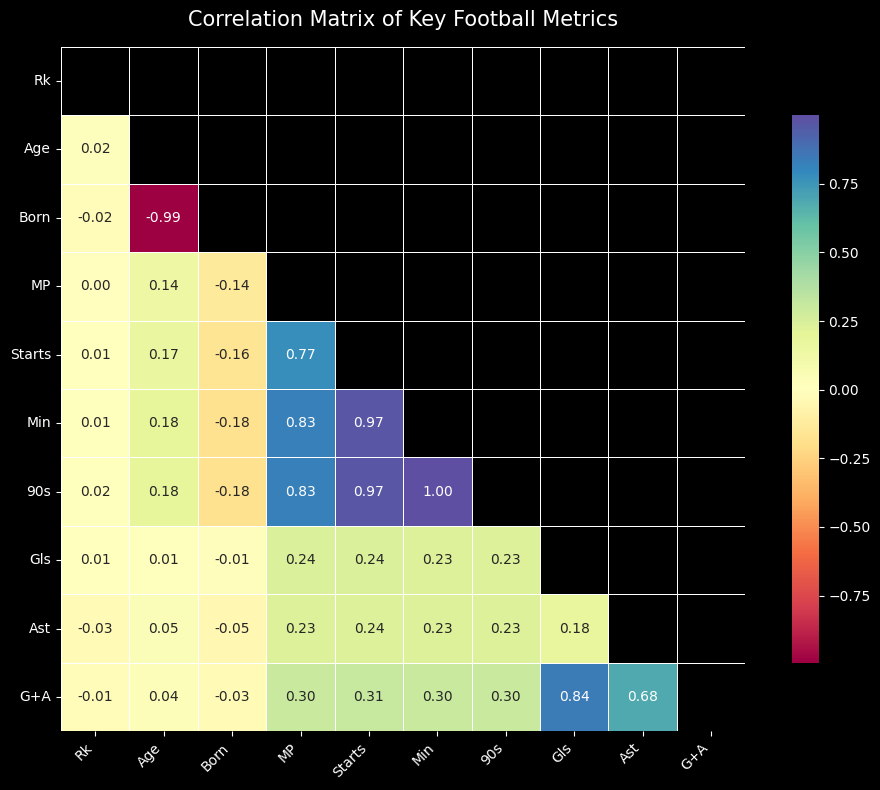

In [3]:
# STEP 3: Exploratory Data Analysis (EDA) - Key Correlation Heatmap

import matplotlib.pyplot as plt
import seaborn as sns

# Set professional visualization style for GitHub
plt.style.use('dark_background')

# Filter a subset of key attacking, passing, and defensive metrics for clarity
keywords = ['goal', 'shot', 'assist', 'pass', 'tackle', 'interception', 'aerial']
selected_cols = [c for c in df_ml.columns if any(k in c.lower() for k in keywords)][:12]

# If fewer matches found, fallback to the first 10 numerical features
if len(selected_cols) < 5:
    selected_cols = df_ml.columns[:10].tolist()

# Compute Pearson correlation matrix
corr = df_ml[selected_cols].corr()

# Mask the upper triangle for better readability
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="Spectral",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix of Key Football Metrics", fontsize=15, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [4]:
# STEP 4: Feature Scaling and K-Means Clustering

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Standardize features to place all metrics on the same scale (mean=0, variance=1)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_ml)

# 2. Initialize and fit K-Means clustering algorithm
# n_clusters=5 groups players into 5 distinct tactical profiles
# random_state ensures reproducible results across different runs
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Role_Cluster'] = kmeans.fit_predict(scaled_features)

# 3. Inspect player distribution across the 5 clusters
cluster_counts = df['Role_Cluster'].value_counts().sort_index()

print("K-Means Clustering Complete!")
print("\nPlayer distribution per cluster:")
for cluster_id, count in cluster_counts.items():
    print(f"Cluster {cluster_id}: {count} players")

K-Means Clustering Complete!

Player distribution per cluster:
Cluster 0: 291 players
Cluster 1: 681 players
Cluster 2: 521 players
Cluster 3: 516 players
Cluster 4: 25 players


Variance explained: PC1 = 20.24%, PC2 = 8.46% (Total = 28.70%)


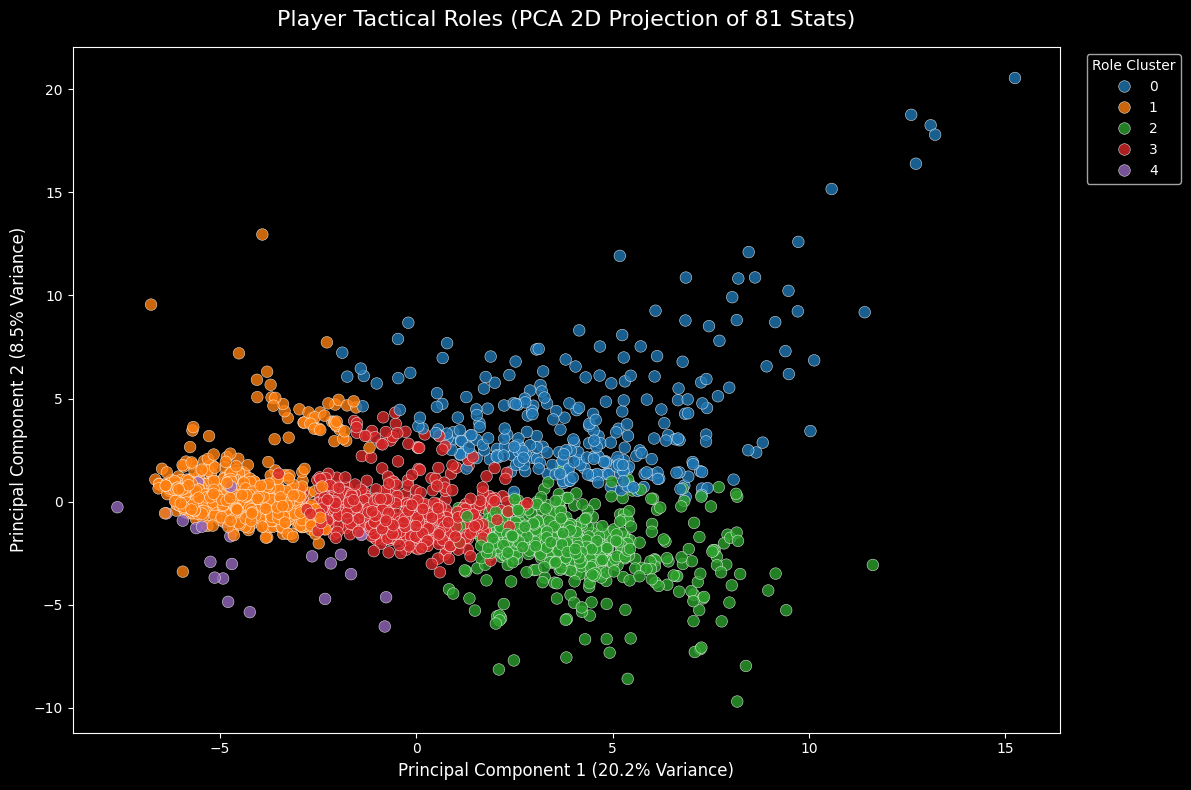

In [5]:
# STEP 5: Dimensionality Reduction via PCA & 2D Cluster Visualization

from sklearn.decomposition import PCA

# Reduce 81-dimensional scaled feature space down to 2 principal components
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(scaled_features)

# Add principal components to original dataframe for visualization
df['PCA_1'] = pca_components[:, 0]
df['PCA_2'] = pca_components[:, 1]

# Calculate percentage of total variance captured by each component
var_1 = pca.explained_variance_ratio_[0] * 100
var_2 = pca.explained_variance_ratio_[1] * 100
total_var = var_1 + var_2

print(f"Variance explained: PC1 = {var_1:.2f}%, PC2 = {var_2:.2f}% (Total = {total_var:.2f}%)")

# Plot 2D scatter plot with clusters
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    x='PCA_1',
    y='PCA_2',
    hue='Role_Cluster',
    palette='tab10',
    data=df,
    alpha=0.8,
    s=70,
    edgecolor='white',
    linewidth=0.4
)

plt.title('Player Tactical Roles (PCA 2D Projection of 81 Stats)', fontsize=16, pad=15)
plt.xlabel(f'Principal Component 1 ({var_1:.1f}% Variance)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({var_2:.1f}% Variance)', fontsize=12)
plt.legend(title='Role Cluster', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

Selected metrics for profiling: ['Saves']


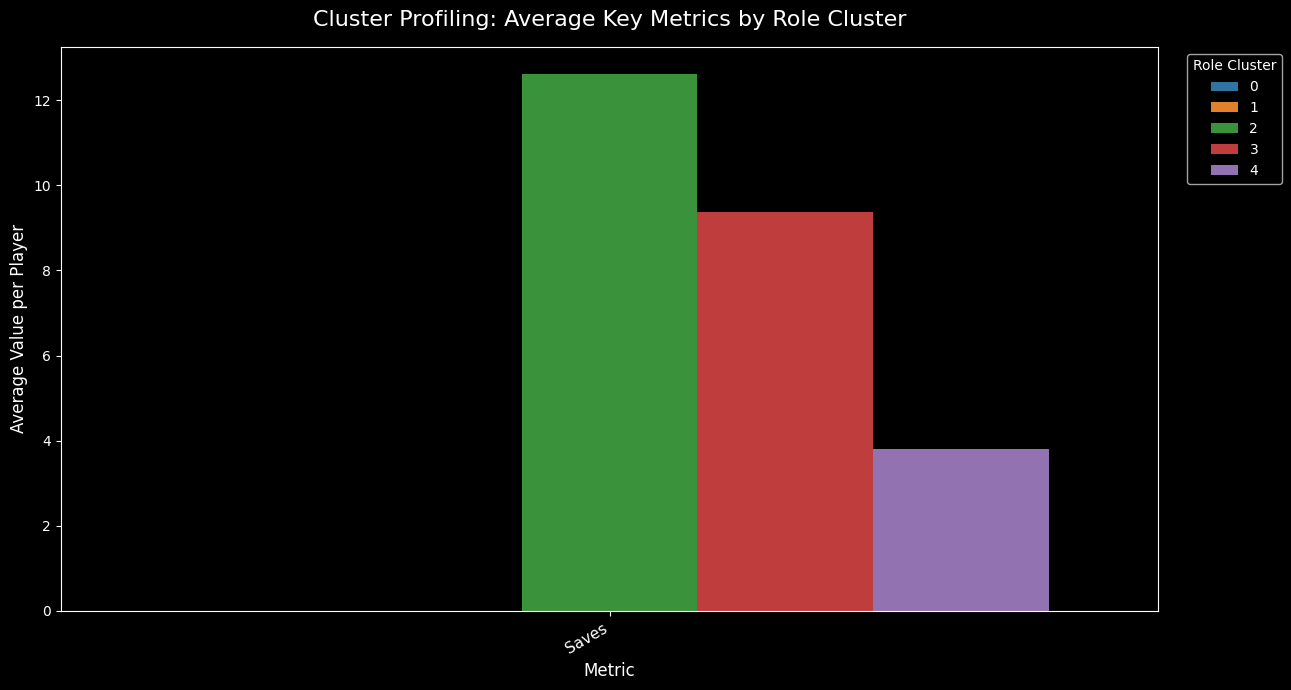


Sample players in Cluster 4 (The 25-player outlier group):


,Player,Role_Cluster
112,Emil Audero,4
165,Augusto Batalla,4
191,Walter Benítez,4
225,Marco Bizot,4
321,Dani Cárdenas,4
465,Rémy Descamps,4
668,Gauthier Gallon,4
804,Ewan Hatfout,4
972,Nicolas Kocik,4
1056,Nicolas Lemaître,4


In [6]:
# STEP 6: Cluster Profiling & Comparative Analysis

# Search dynamically for key performance metrics in the dataset
stat_candidates = [
    'Goals', 'Assists', 'Shots', 'Passes', 'Passes_Completed',
    'Tackles', 'Interceptions', 'Clearances', 'Key_Passes', 'Saves'
]

# Match candidates against actual column names in df (case-insensitive)
matched_stats = []
for candidate in stat_candidates:
    for col in df.columns:
        if candidate.lower() == col.lower() or (candidate.lower() in col.lower() and col in df_ml.columns):
            if col not in matched_stats:
                matched_stats.append(col)
                break

# Limit to top 5-6 key stats for a clear visualization
matched_stats = matched_stats[:6] if len(matched_stats) >= 6 else matched_stats

print(f"Selected metrics for profiling: {matched_stats}")

# Calculate mean performance per cluster for these metrics
cluster_means = df.groupby('Role_Cluster')[matched_stats].mean().reset_index()

# Melt the dataframe for Seaborn grouped barplot
cluster_melted = pd.melt(
    cluster_means,
    id_vars=['Role_Cluster'],
    value_vars=matched_stats,
    var_name='Metric',
    value_name='Average_Value'
)

# Plot grouped bar chart
plt.figure(figsize=(13, 7))
barplot = sns.barplot(
    x='Metric',
    y='Average_Value',
    hue='Role_Cluster',
    data=cluster_melted,
    palette='tab10'
)

plt.title('Cluster Profiling: Average Key Metrics by Role Cluster', fontsize=16, pad=15)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Average Value per Player', fontsize=12)
plt.xticks(rotation=30, ha='right', fontsize=11)
plt.legend(title='Role Cluster', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

# Quick inspection of players in the rare cluster (Cluster 4)
# Identify the player name column (e.g., 'player', 'Player', 'name', 'Name')
name_col = next((col for col in ['Player', 'player', 'Name', 'name'] if col in df.columns), None)

if name_col:
    print("\nSample players in Cluster 4 (The 25-player outlier group):")
    display(df[df['Role_Cluster'] == 4][[name_col, 'Role_Cluster']].head(10))

In [7]:
# STEP 7: Player Recommendation System using Cosine Similarity

from sklearn.metrics.pairwise import cosine_similarity

# Compute pairwise cosine similarity matrix across all players using scaled features
similarity_matrix = cosine_similarity(scaled_features)
print(f"Similarity matrix calculated with shape: {similarity_matrix.shape}")

# Automatically detect player name column
name_col = next((col for col in ['Player', 'player', 'Name', 'name'] if col in df.columns), None)

def recommend_similar_players(player_name, top_n=5):
    """
    Finds and ranks the top N most similar players based on statistical profile.
    """
    if not name_col:
        print("Error: Player name column not found in dataset.")
        return None

    # Locate player index matching the input string (case-insensitive)
    matches = df[df[name_col].str.contains(player_name, case=False, na=False)]

    if matches.empty:
        print(f"No player found matching '{player_name}'.")
        return None

    target_idx = matches.index[0]
    target_name = df.loc[target_idx, name_col]
    target_cluster = df.loc[target_idx, 'Role_Cluster']

    # Retrieve similarity scores for the target player
    scores = list(enumerate(similarity_matrix[target_idx]))

    # Sort players by descending similarity score
    sorted_scores = sorted(scores, key=lambda x: x[1], reverse=True)

    # Exclude the target player (index 0 is self-similarity: 100%)
    top_matches = sorted_scores[1:top_n + 1]
    top_indices = [idx for idx, _ in top_matches]
    top_similarities = [score for _, score in top_matches]

    # Build results table
    display_fields = [name_col, 'Role_Cluster']
    for extra in ['Squad', 'Team', 'Age', 'Pos', 'Position']:
        if extra in df.columns:
            display_fields.append(extra)

    results_df = df.iloc[top_indices][display_fields].copy()
    results_df['Similarity'] = [f"{s * 100:.1f}%" for s in top_similarities]

    print(f"\n=======================================================")
    print(f"Target: {target_name} | Role Cluster: {target_cluster}")
    print(f"Top {top_n} Statistically Similar Players:")
    print(f"=======================================================")
    return results_df

# Quick test with a player (search is case-insensitive)
# Replace 'a' with any player name from your dataset to test
test_results = recommend_similar_players('a', top_n=5)
if test_results is not None:
    display(test_results)

Similarity matrix calculated with shape: (2034, 2034)

Target: Brenden Aaronson | Role Cluster: 3
Top 5 Statistically Similar Players:


,Player,Role_Cluster,Squad,Age,Pos,Similarity
230,Jeremie Boga,3,Juventus,29.0,MF,74.9%
262,Marco Brescianini,3,Fiorentina,26.0,MF,73.7%
268,Nathaniel Brown,3,Bayern Munich,23.0,"MF,DF",73.6%
19,Tyler Adams,3,Bournemouth,27.0,MF,68.8%
46,Maghnes Akliouche,3,Paris SG,24.0,FW,67.9%
